# Final project


In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.signal import savgol_filter
from scipy.fft import rfft, irfft, rfftfreq
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error




In [83]:
BASE_DIR = Path.cwd()
if BASE_DIR.name != 'final_project':
    BASE_DIR = Path('ts-magi-2025-2026-main/final_project')

DT = 0.05
N_HISTORY = 4000
N_FORECAST = 1000
HORIZON = np.arange(N_FORECAST) * DT

train = pd.read_csv(BASE_DIR / 'train.csv', header=None).values
test = pd.read_csv(BASE_DIR / 'test.csv', header=None).values
etalon_train = pd.read_csv(BASE_DIR / 'etalon_for_train.csv', header=None).values
etalon_test = pd.read_csv(BASE_DIR / 'etalon_for_test.csv', header=None).values

print(train.shape, test.shape, etalon_train.shape, etalon_test.shape)




(1000, 5000) (500, 5000) (1000, 5000) (500, 5000)


In [84]:
X = train[:, :N_HISTORY]
y = etalon_train[:, N_HISTORY:N_HISTORY + N_FORECAST]
X_test = test[:, :N_HISTORY]
y_test = etalon_test[:, N_HISTORY:N_HISTORY + N_FORECAST]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)




(800, 4000) (200, 4000) (800, 1000) (200, 1000)


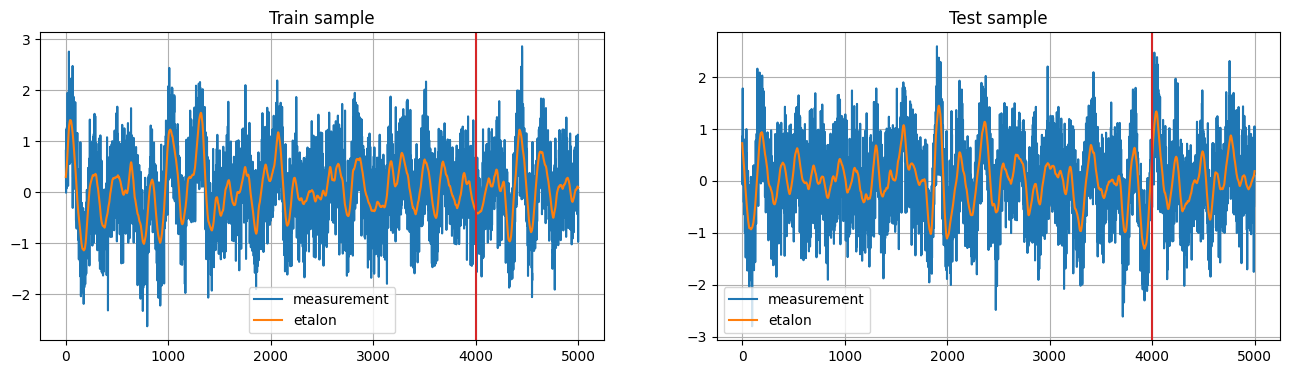

In [85]:
idx = 0
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))
ax[0].plot(train[idx], label='measurement')
ax[0].plot(etalon_train[idx], label='etalon')
ax[0].axvline(N_HISTORY, color='tab:red')
ax[0].set_title('Train sample')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(test[idx], label='measurement')
ax[1].plot(etalon_test[idx], label='etalon')
ax[1].axvline(N_HISTORY, color='tab:red')
ax[1].set_title('Test sample')
ax[1].grid(True)
ax[1].legend()
plt.show()




In [86]:
def evaluate_forecast(y_true, y_pred):
    err = y_pred - y_true
    mean_error = err.mean(axis=0)
    rms_by_time = err.std(axis=0, ddof=1)

    return {
        'mse': np.mean(err ** 2),
        'rmse': np.sqrt(np.mean(err ** 2)),
        'mae': np.mean(np.abs(err)),
        'mean_error': mean_error,
        'rms_by_time': rms_by_time,
    }

validation_results = []

def add_validation_result(name, y_pred):
    metrics = evaluate_forecast(y_valid, y_pred)
    validation_results.append({
        'model': name,
        'mse': metrics['mse'],
        'rmse': metrics['rmse'],
        'mae': metrics['mae'],
    })
    print(name, metrics['mse'], metrics['rmse'], metrics['mae'])
    return metrics




In [87]:
def smooth_persistence_forecast(X_input, window=101, polyorder=3):
    if window % 2 == 0:
        window += 1
    smoothed = savgol_filter(X_input, window_length=window, polyorder=polyorder, axis=1)
    last_level = smoothed[:, -1:]
    return np.repeat(last_level, N_FORECAST, axis=1)

valid_smooth_pred = smooth_persistence_forecast(X_valid)
smooth_metrics = add_validation_result('smooth_persistence', valid_smooth_pred)




smooth_persistence 0.5667862378482278 0.7528520690336368 0.5930083906083887


In [88]:
def fourier_forecast_one(series, n_predict=N_FORECAST, n_harm=25):
    y_center = series - np.mean(series)
    n = y_center.size
    freqs = rfftfreq(n, d=DT)
    spectrum = rfft(y_center)
    order = np.argsort(np.abs(spectrum))[::-1]
    t = np.arange(n + n_predict) * DT
    restored = np.zeros(n + n_predict)
    used = 0
    for idx in order:
        if idx == 0:
            continue
        amplitude = 2 * np.abs(spectrum[idx]) / n
        phase = np.angle(spectrum[idx])
        restored += amplitude * np.cos(2 * np.pi * freqs[idx] * t + phase)
        used += 1
        if used >= n_harm:
            break
    restored += np.mean(series)
    return restored[-n_predict:]

def fourier_forecast(X_input, n_harm=25):
    return np.vstack([fourier_forecast_one(row, n_predict=N_FORECAST, n_harm=n_harm) for row in X_input])

valid_fourier_pred = fourier_forecast(X_valid, n_harm=25)
fourier_metrics = add_validation_result('fourier_25', valid_fourier_pred)




fourier_25 0.5252281239772213 0.7247262407124647 0.5797399946322135


In [89]:
pca_components = 160
alphas = [0.1, 1.0, 10.0, 100.0, 500.0]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

pca = PCA(n_components=pca_components, svd_solver='randomized', random_state=42)
Z_train = pca.fit_transform(X_train_scaled)
Z_valid = pca.transform(X_valid_scaled)

ridge_results = []
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(Z_train, y_train)
    pred = model.predict(Z_valid)
    metrics = evaluate_forecast(y_valid, pred)
    ridge_results.append({'alpha': alpha, 'mse': metrics['mse'], 'rmse': metrics['rmse'], 'mae': metrics['mae']})

ridge_results = pd.DataFrame(ridge_results).sort_values('mse').reset_index(drop=True)
ridge_results




,alpha,mse,rmse,mae
0,500.0,0.273061,0.522552,0.414516
1,100.0,0.274261,0.523700,0.415370
2,10.0,0.274577,0.524001,0.415596
3,1.0,0.274610,0.524032,0.415619
4,0.1,0.274613,0.524035,0.415622


In [90]:
best_alpha = ridge_results.loc[0, 'alpha']
ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(Z_train, y_train)
valid_ridge_pred = ridge_model.predict(Z_valid)
ridge_metrics = add_validation_result(f'pca_ridge_{best_alpha}', valid_ridge_pred)


pca_ridge_500.0 0.2730608495074968 0.5225522457204608 0.41451554168773674


In [91]:
validation_results = pd.DataFrame(validation_results).sort_values('mse').reset_index(drop=True)
validation_results




,model,mse,rmse,mae
0,pca_ridge_500.0,0.273061,0.522552,0.414516
1,fourier_25,0.525228,0.724726,0.579740
2,smooth_persistence,0.566786,0.752852,0.593008


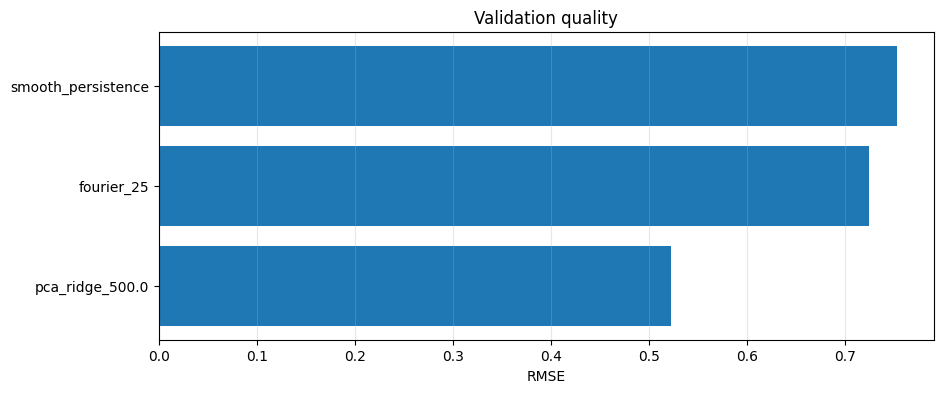

In [92]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(validation_results['model'], validation_results['rmse'])
ax.set_xlabel('RMSE')
ax.set_title('Validation quality')
ax.grid(True, axis='x', alpha=0.3)
plt.show()




In [93]:
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=pca_components, svd_solver='randomized', random_state=42)
Z = pca.fit_transform(X_scaled)
Z_test = pca.transform(X_test_scaled)

final_model = Ridge(alpha=best_alpha)
final_model.fit(Z, y)
test_pred = final_model.predict(Z_test)

test_metrics = evaluate_forecast(y_test, test_pred)
print('MSE:', test_metrics['mse'])
print('RMSE:', test_metrics['rmse'])
print('MAE:', test_metrics['mae'])




MSE: 0.26594567009723913
RMSE: 0.5156992050577925
MAE: 0.41178975796716805


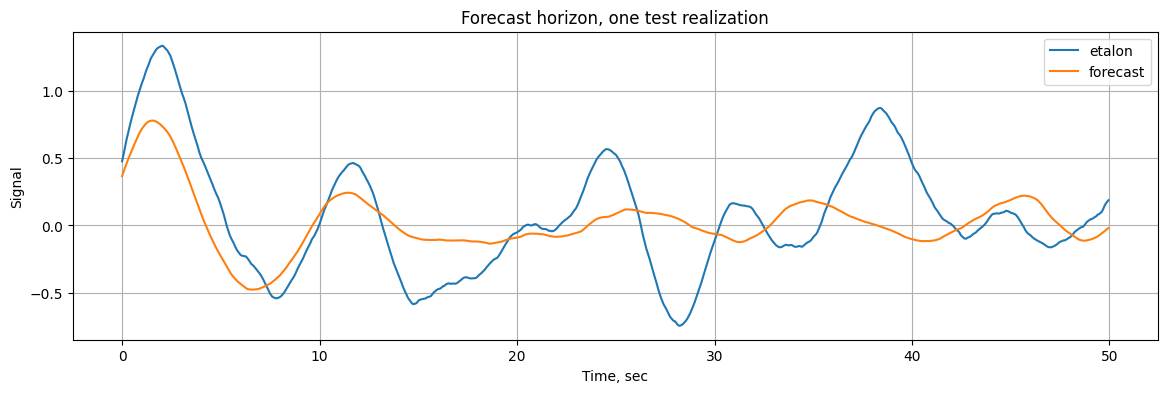

In [94]:
idx = 0
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(HORIZON, y_test[idx], label='etalon')
ax.plot(HORIZON, test_pred[idx], label='forecast')
ax.set_title('Forecast horizon, one test realization')
ax.set_xlabel('Time, sec')
ax.set_ylabel('Signal')
ax.grid(True)
ax.legend()
plt.show()




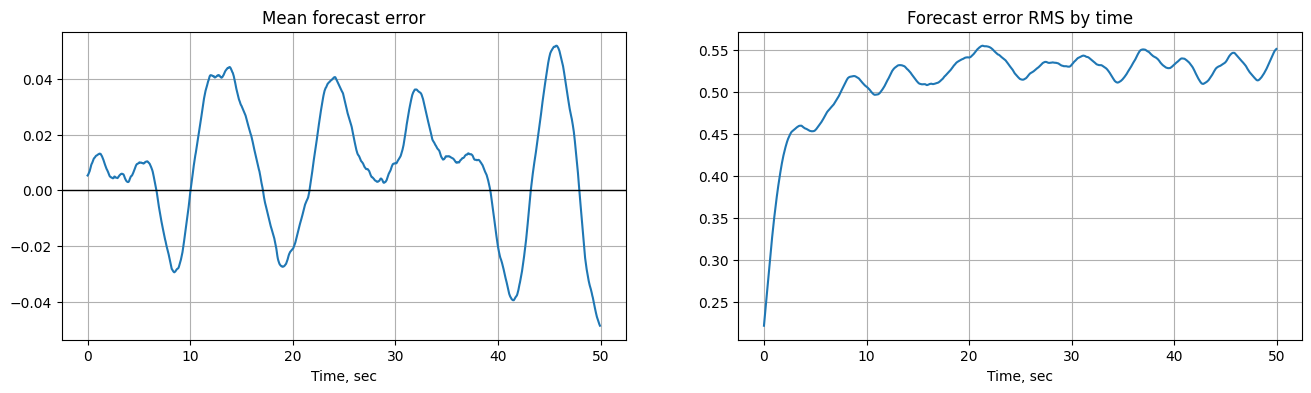

In [95]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))
ax[0].plot(HORIZON, test_metrics['mean_error'])
ax[0].axhline(0, color='k', linewidth=1)
ax[0].set_title('Mean forecast error')
ax[0].set_xlabel('Time, sec')
ax[0].grid(True)

ax[1].plot(HORIZON, test_metrics['rms_by_time'])
ax[1].set_title('Forecast error RMS by time')
ax[1].set_xlabel('Time, sec')
ax[1].grid(True)
plt.show()
